In [3]:
from cuda_cqed.sim import Sim
# import gpu_odes.HatGPUODE_D
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use('Qt5Agg')
%matplotlib inline

In [28]:
pi = np.pi

sim = Sim(use_complex=True)

sim.add_param('sqrtka_ext', np.sqrt(1e6*2*pi)) # in MHz
sim.add_param('ka_int', 0e6*2*pi) # in MHz
sim.add_param('amplR',  0.01)
sim.add_param('wa', 0, is_excitation=True)
# sim.add_paramsweep('wa', 4.99e9*2*pi, 5.01e9*2*pi, 101)  #this simulates a slow dephasing effect
sim.add_param('wR', 0e9 * 2 * np.pi)
sim.add_param('rampR', 1e-9)
sim.add_param('startR', 5e-9)
sim.add_param('stopR', 200e-9)
sim.add_param('phaseR', 0)
sim.add_paramsweep('sigmaZ', -1, 1, 2)
sim.add_param('chi', 1e6*2*np.pi)

Rpulse = sim.make_pulse('wR', 'amplR', 'phaseR', 'startR', 'stopR', 'rampR')

sim.add_EOM('ain', Rpulse)

# sim.add_EOM('a', '-1j*wa*a - ain*sqrtka_ext - (sqrtka_ext**2 + ka_int)/2*a')
sim.set_solve_type('all')

sim.specify_time(t_f=5e-8, pts=10001)

sim.validate()

Recent change to specify_time(), check implementation
Simulation validation success!


In [31]:
Rpulse

'amplR/2*wR*exp(-1j*(wR*t +phaseR))*(tanh((t-startR)/rampR)-tanh((t-stopR)/rampR))'

Simulation validation success!
Running CPU quick solve...
...finished CPU quick solve!


C:\Users\boris\AppData\Local\Temp\ipykernel_21976\767270053.py:5: RuntimeWarning: invalid value encountered in divide
  plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a in')
C:\Users\boris\AppData\Local\Temp\ipykernel_21976\767270053.py:6: RuntimeWarning: invalid value encountered in divide
  plt.plot(t*1e9, x[1,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a in')


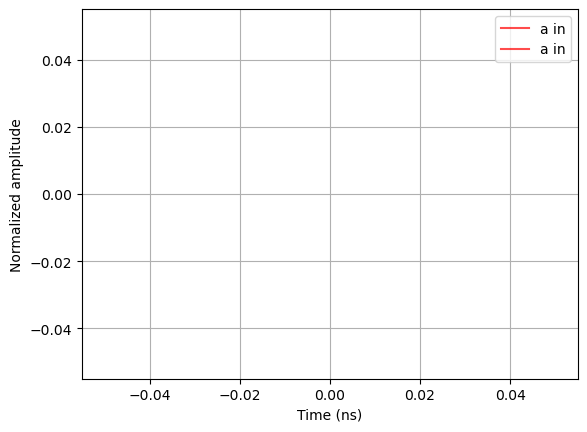

In [29]:
x, t = sim.quick_trace()

plt.figure(1)
plt.clf()
plt.plot(t*1e9, x[0,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a in')
plt.plot(t*1e9, x[1,:]/np.max(x[0,:]),color=(1,0,0,0.7),label='a in')
plt.xlabel('Time (ns)')
plt.ylabel('Normalized amplitude')
plt.legend()
plt.grid()
plt.show()

In [30]:
x

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [5]:
I, Q, t = sim.solve()

Simulation validation success!
Running GPU solve...


100%|██████████████████████████████████████████████████████████████████████████| 10000/10000 [00:05<00:00, 1776.11it/s]


 
...finished GPU solve!


In [6]:
Id = I.copy()
Qd = Q.copy()
td = t.copy()

ain = Id[0,:]+1j*Qd[0,:]
a = Id[2,:]+1j*Qd[2,:]

aout = ain + sim.param_dict['sqrtka_ext']*a

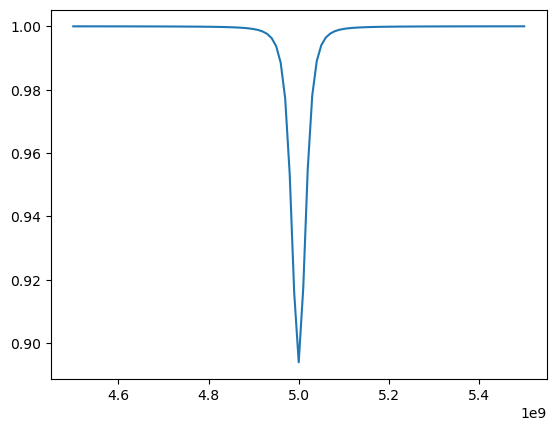

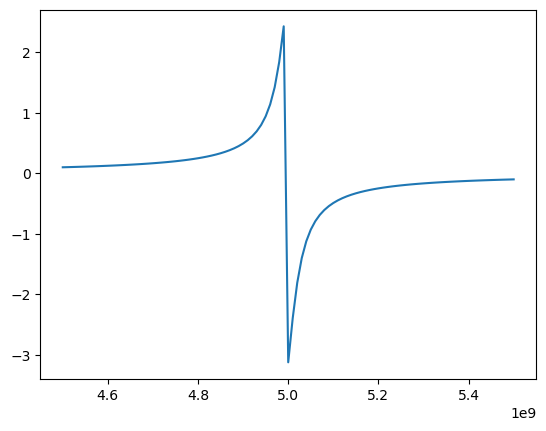

In [7]:
S11 = np.mean(aout[:,:,-1]/ain[:,:,-1], axis=0)

wR = sim.paramsweep_dict['wR']/(2*np.pi)
wa = sim.paramsweep_dict['wa']/(2*np.pi)

plt.plot(wR, np.abs(S11))
plt.show()
plt.plot(wR,np.angle(S11))
plt.show()